In [2]:
from transformers import GPT2LMHeadModel

c:\Users\benha\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
model_hf = GPT2LMHeadModel.from_pretrained("gpt2") # 124M
sd_hf = model_hf.state_dict()

for k, v in sd_hf.items():
    print(k, v.shape)

Loading weights: 100%|██████████| 148/148 [00:00<00:00, 3781.71it/s]

transformer.wte.weight torch.Size([50257, 768])
transformer.wpe.weight torch.Size([1024, 768])
transformer.h.0.ln_1.weight torch.Size([768])
transformer.h.0.ln_1.bias torch.Size([768])
transformer.h.0.attn.c_attn.weight torch.Size([768, 2304])
transformer.h.0.attn.c_attn.bias torch.Size([2304])
transformer.h.0.attn.c_proj.weight torch.Size([768, 768])
transformer.h.0.attn.c_proj.bias torch.Size([768])
transformer.h.0.ln_2.weight torch.Size([768])
transformer.h.0.ln_2.bias torch.Size([768])
transformer.h.0.mlp.c_fc.weight torch.Size([768, 3072])
transformer.h.0.mlp.c_fc.bias torch.Size([3072])
transformer.h.0.mlp.c_proj.weight torch.Size([3072, 768])
transformer.h.0.mlp.c_proj.bias torch.Size([768])
transformer.h.1.ln_1.weight torch.Size([768])
transformer.h.1.ln_1.bias torch.Size([768])
transformer.h.1.attn.c_attn.weight torch.Size([768, 2304])
transformer.h.1.attn.c_attn.bias torch.Size([2304])
transformer.h.1.attn.c_proj.weight torch.Size([768, 768])
transformer.h.1.attn.c_proj.bias 

In [4]:
sd_hf["transformer.wpe.weight"].view(-1)[:20]

tensor([-0.0188, -0.1974,  0.0040,  0.0113,  0.0638, -0.1050,  0.0369, -0.1680,
        -0.0491, -0.0565, -0.0025,  0.0135, -0.0042,  0.0151,  0.0166, -0.1381,
        -0.0063, -0.0461,  0.0267, -0.2042])

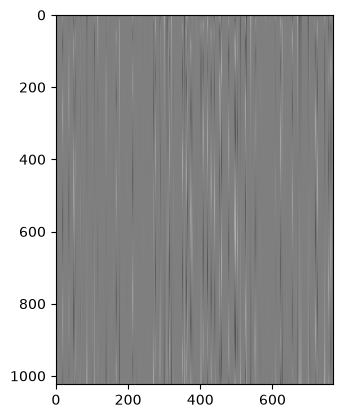

In [5]:
import matplotlib.pyplot as plt
%matplotlib inline

w = sd_hf["transformer.wpe.weight"]
w_centered = w - w.mean(dim=0)          # subtract the per-column average
plt.imshow(w_centered, cmap="gray", vmin=-w_centered.abs().max()/4, vmax=w_centered.abs().max()/4)

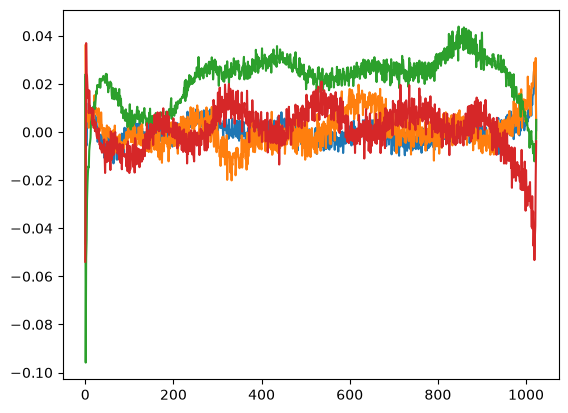

In [6]:
plt.plot(sd_hf["transformer.wpe.weight"][:, 150])
plt.plot(sd_hf["transformer.wpe.weight"][:, 200])
plt.plot(sd_hf["transformer.wpe.weight"][:, 250])
# plt.plot(sd_hf["transformer.wpe.weight"][:, 300]) # this one is on a totally different scale
# plt.plot(sd_hf["transformer.wpe.weight"][:, 359])
# plt.plot(sd_hf["transformer.wpe.weight"][:, 413])
plt.plot(sd_hf["transformer.wpe.weight"][:, 450])

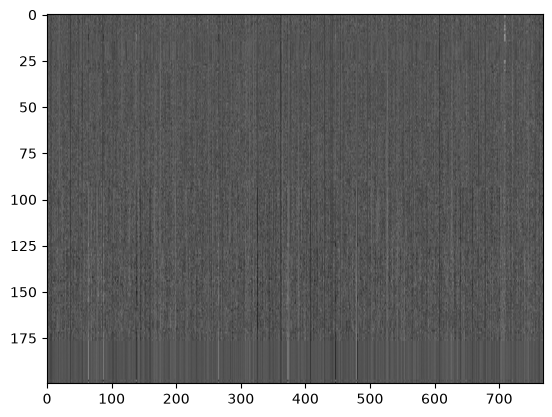

Text(0, 0.5, '768 dim L2 vector length')

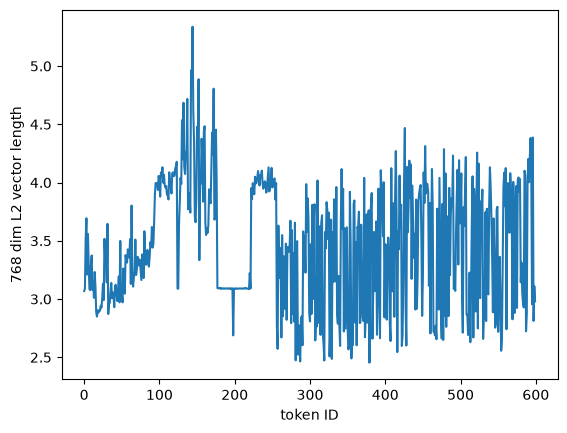

In [7]:
## visualize the wte token to embedding lookup table (these are learned weights)

wte = sd_hf["transformer.wte.weight"]   # [50257, 768]

plt.imshow(wte[:200], cmap="gray", aspect="auto") 
plt.show()

# L2 norm (vector length) of each token embedding for the first 600 token IDs
norms = wte[:600].norm(dim=1)   # [600, 768] -> [600]; dim=1 collapses the 768 embedding dims

# x-axis: token ID, y-axis: embedding norm (look for level shifts, e.g. byte tokens vs. merged tokens)
plt.plot(norms)
plt.xlabel("token ID")
plt.ylabel("768 dim L2 vector length")

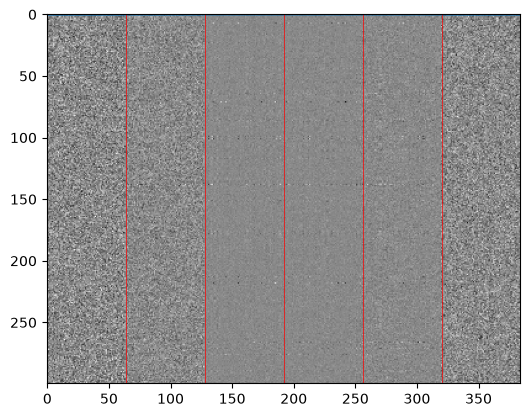

In [8]:
head_size = 64
x_axis = head_size * 6

plt.imshow(sd_hf["transformer.h.1.attn.c_attn.weight"][:300,:x_axis], cmap="gray")
# From the grayscale plot defined above I can distinctly see columns about every 64 on the X axis which happens to be the same size as each attention head in the multi-headed attention

# The logic below overlays red lines every 64 i think this shows that each attention head learns on a different scale. However if you look at the end of the GPT (transformer 11) this graph will look uniform.
w = sd_hf["transformer.h.1.attn.c_attn.weight"]
std_per_col = w[:, :x_axis].std(dim=0)          # Q part only
plt.plot(std_per_col)
for i in range(0, x_axis, head_size): plt.axvline(i, color="r", lw=0.5)

# T = 1024 (context length)
## transformer for reference
# transformer.h.0.ln_1.weight        [768]
# transformer.h.0.ln_1.bias          [768]
# transformer.h.0.attn.c_attn.weight [768, 2304]   <<-- we are here (Q|K|V concatenated)
# transformer.h.0.attn.c_attn.bias   [2304]
#     -> split Q, K, V [T,768] each into 12 heads of 64 -> [12, T, 64]
#     -> score every token pair per head: Q_h [T,64] @ K_hᵀ [64,T] -> [12, T, T]
#        (scaled by √64, causal mask applied)
#     -> softmax over each row (no weights, code only) -> [12, T, T]
#     -> multiply by V_h [T,64] -> [12, T, 64]
#     -> concat heads side by side -> [T, 768]
# transformer.h.0.attn.c_proj.weight [768, 768] # these are learned weights to "mix" all of the heads back together
# transformer.h.0.attn.c_proj.bias   [768]
#     -> + residual
# transformer.h.0.ln_2.weight        [768]
# transformer.h.0.ln_2.bias          [768]
# transformer.h.0.mlp.c_fc.weight    [768, 3072]
# transformer.h.0.mlp.c_fc.bias      [3072]
#     -> GELU  (nonlinearity, no weights, code only)
# transformer.h.0.mlp.c_proj.weight  [3072, 768]
# transformer.h.0.mlp.c_proj.bias    [768]
#     -> + residual

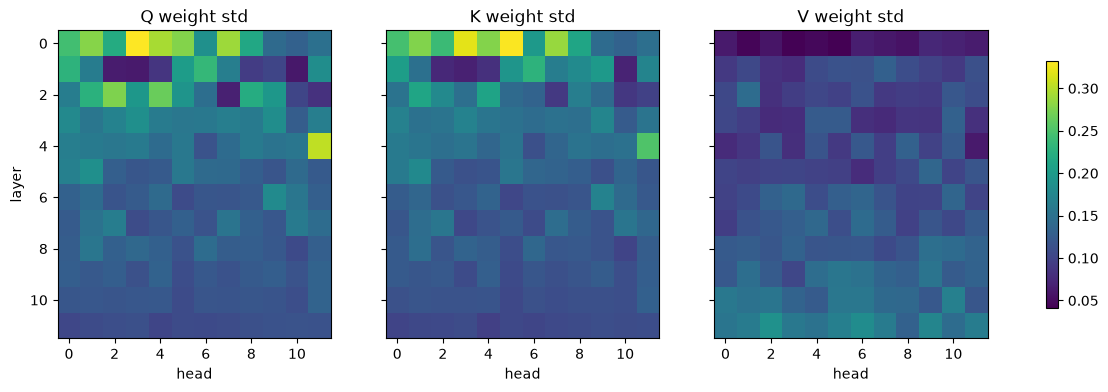

In [9]:
# The plot below compares the QK and V matrices: standard deviation=color y axis=layer x axis=attention head
# we take std of all values in each [768,64] head
# To me it makes sense that the Q and K matrices match very closely becuase we use Q to search for a matching K which will return a V

names = ["Q", "K", "V"]
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

# one shared color scale so Q, K, V are directly comparable
all_stds = []
for L in range(12):
    w = sd_hf[f"transformer.h.{L}.attn.c_attn.weight"]            # [768, 2304]
    # split columns into Q|K|V, then into 12 heads of 64; std per head
    per_head = torch.stack([
        w[:, i*768:(i+1)*768].reshape(768, 12, 64).std(dim=(0, 2))
        for i in range(3)
    ])                                                            # [3, 12]
    all_stds.append(per_head)
stds = torch.stack(all_stds)                                      # [layer=12, qkv=3, head=12]

vmin, vmax = stds.min().item(), stds.max().item()
for i, ax in enumerate(axes):
    im = ax.imshow(stds[:, i, :], aspect="auto", vmin=vmin, vmax=vmax)
    ax.set_title(f"{names[i]} weight std")
    ax.set_xlabel("head")
axes[0].set_ylabel("layer")
fig.colorbar(im, ax=axes, shrink=0.8)
plt.show()

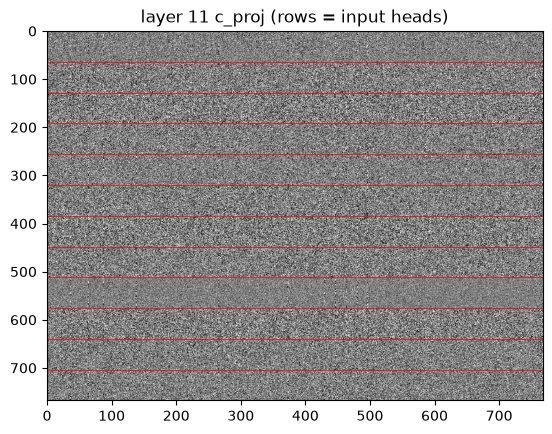

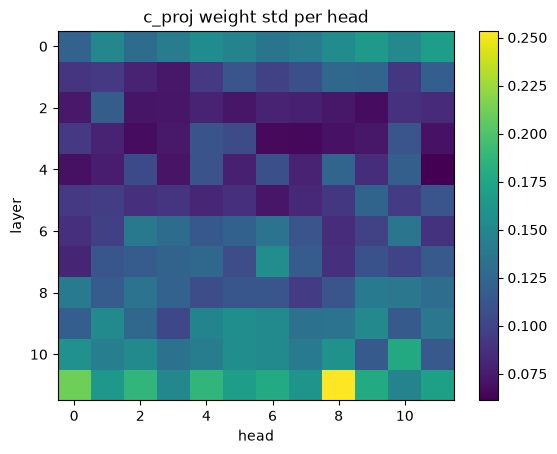

In [10]:
# The projection matrix is "mixing" the results of the concatenated multi-headed attention back together and so my hypothesis why we see some variation between every 64 rows is that its influence by the multi headed attention in it this is kind of learning each attention heads tendencies so it can mix them back together effectively

# 1. Raw image of one layer, red lines at head boundaries (rows)
L = 11
w = sd_hf[f"transformer.h.{L}.attn.c_proj.weight"]
plt.imshow(w, cmap="gray", aspect="auto", vmin=-0.3, vmax=0.3)
for i in range(0, 768, 64):
    plt.axhline(i, color="r", lw=0.5)
plt.title(f"layer {L} c_proj (rows = input heads)")
plt.show()

# 2. Weight scale per head (row-block) across all layers
stds = torch.stack([
    sd_hf[f"transformer.h.{L}.attn.c_proj.weight"].reshape(12, 64, 768).std(dim=(1, 2))
    for L in range(12)
])                                                    # [layer, head]
plt.imshow(stds, aspect="auto"); plt.colorbar()
plt.xlabel("head"); plt.ylabel("layer"); plt.title("c_proj weight std per head")
plt.show()


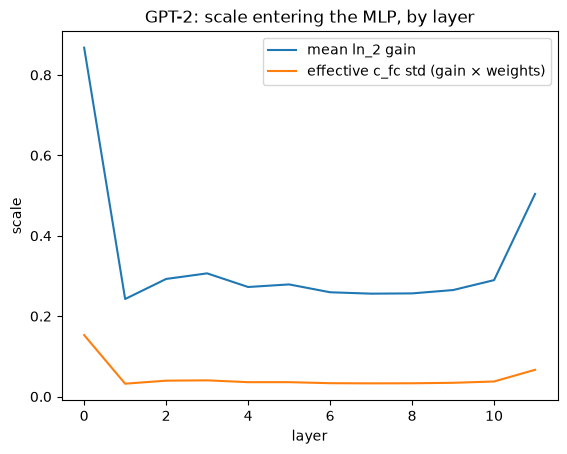

In [11]:
# Does the LayerNorm gain before the MLP (ln_2) track the overall scale seen by c_fc?
# Compare the raw gain with the "effective" scale (gain folded into the c_fc weights).

## MY THINKING: Larger effective gain when we multiply the layer norm by the weights of the MLP Means that the output values of the MLP are going to be larger Umm which makes this layer umm acts like a sharper on or off switch there's not much in the middle if that makes sense It's either zero or it's a large number because when we pass all the MLP weights through the nonlinearity we are left with lots of 0s and lots of large numbers. SEE BELOW FOR POST NONLINEARITY WEIGHTS

mean_gain, eff_std = [], []
for L in range(12):
    g = sd_hf[f"transformer.h.{L}.ln_2.weight"]          # [768]  LayerNorm gain, one per dimension
    w = sd_hf[f"transformer.h.{L}.mlp.c_fc.weight"]      # [768, 3072]  MLP expansion weights

    mean_gain.append(g.mean().item())                    # raw gain, averaged over the 768 dims
    eff_std.append((g[:, None] * w).std().item())        # gain scales each input row of w, then std

plt.plot(mean_gain, label="mean ln_2 gain")
plt.plot(eff_std, label="effective c_fc std (gain × weights)")
plt.title("GPT-2: scale entering the MLP, by layer")
plt.xlabel("layer")
plt.ylabel("scale")
plt.legend()
plt.show()


Loading weights: 100%|██████████| 148/148 [00:00<00:00, 8085.19it/s]


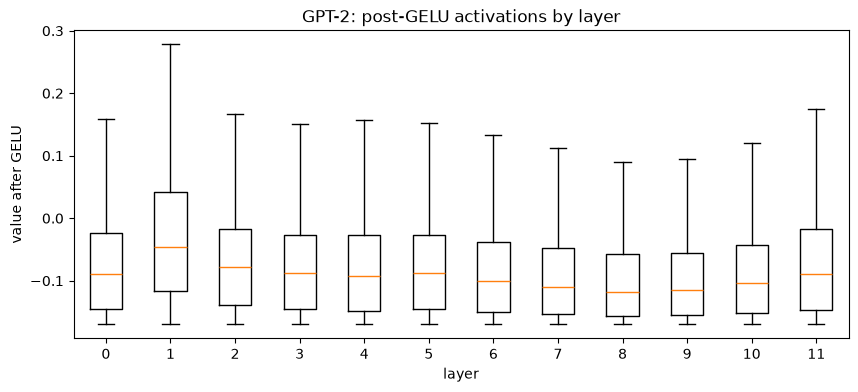

In [12]:
import torch, matplotlib.pyplot as plt
from transformers import GPT2LMHeadModel, GPT2TokenizerFast

model = GPT2LMHeadModel.from_pretrained("gpt2").eval()
tok = GPT2TokenizerFast.from_pretrained("gpt2")

# Capture the output of GELU (post-activation) in every layer
post_gelu = {}
def make_hook(L):
    def hook(module, inp, out):
        post_gelu[L] = out.detach().flatten()     # [T, 3072] -> 1D
    return hook

for L, block in enumerate(model.transformer.h):
    block.mlp.act.register_forward_hook(make_hook(L))   # hook the GELU itself, not c_fc

# Run some real text through the model
text = "The quick brown fox jumps over the lazy dog. " * 20
ids = tok(text, return_tensors="pt", truncation=True, max_length=512)
with torch.no_grad():
    model(**ids)

# Distribution per layer (violin plot)
plt.figure(figsize=(10, 4))
data = [post_gelu[L][post_gelu[L] <= torch.quantile(post_gelu[L], 1)].numpy() for L in range(12)]
plt.boxplot(data, showfliers=False)
plt.xticks(range(1, 13), range(12))
plt.xlabel("layer"); plt.ylabel("value after GELU")
plt.title("GPT-2: post-GELU activations by layer")
plt.show()

# My hypothesis on the previous cell does not seem to hold when we visualize the post non-linearity activation values this way.

Loading weights: 100%|██████████| 148/148 [00:00<00:00, 7665.18it/s]


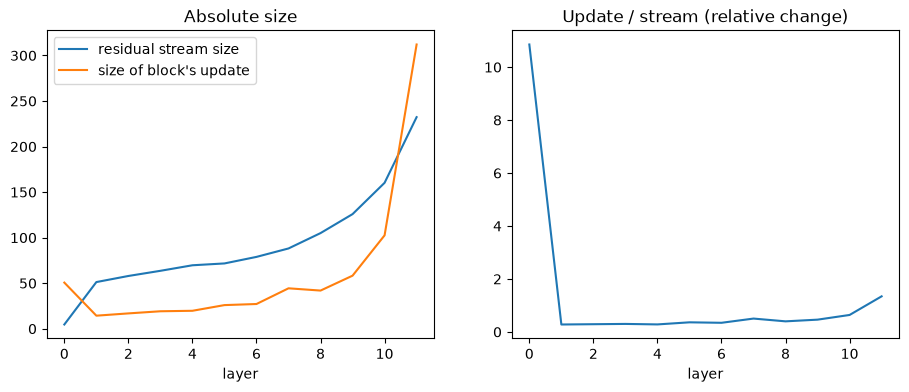

In [13]:
import torch, matplotlib.pyplot as plt
from transformers import GPT2LMHeadModel, GPT2TokenizerFast

model = GPT2LMHeadModel.from_pretrained("gpt2").eval()
tok = GPT2TokenizerFast.from_pretrained("gpt2")

stream_norm, update_norm = {}, {}

def make_hook(L):
    def hook(module, inp, out):
        x_in = inp[0]                                   # residual stream entering the block
        x_out = out[0] if isinstance(out, tuple) else out   # stream leaving the block
        update = x_out - x_in                           # what this block added
        # norm per token, skip token 0 (GPT-2 gives it a huge, atypical norm)
        stream_norm[L] = x_in[0, 1:].norm(dim=-1).median().item()
        update_norm[L] = update[0, 1:].norm(dim=-1).median().item()
    return hook

for L, block in enumerate(model.transformer.h):
    block.register_forward_hook(make_hook(L))

text = ("Natural language models learn statistical patterns from text. "
        "The weather today is sunny, and the market closed higher after a strong earnings report. "
        "She opened the old book and began to read about ancient Rome. ") * 3
ids = tok(text, return_tensors="pt", truncation=True, max_length=512)
with torch.no_grad():
    model(**ids)

layers = range(12)
stream = [stream_norm[L] for L in layers]
update = [update_norm[L] for L in layers]
ratio = [u / s for u, s in zip(update, stream)]

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(stream, label="residual stream size")
ax[0].plot(update, label="size of block's update")
ax[0].set_title("Absolute size"); ax[0].set_xlabel("layer"); ax[0].legend()
ax[1].plot(ratio)
ax[1].set_title("Update / stream (relative change)"); ax[1].set_xlabel("layer")
plt.show()

# This is showing the stream which is the input to each transformer and then the size (norm or vector length) of block update which is like how much the transformer updates that stream it's basically showing that as the stream increases in size throughout the layers The updates that each transformer make to it also increase relatively proportionally to that 


In [14]:
from transformers import pipeline, set_seed
generator = pipeline('text-generation', model='gpt2')
set_seed(42)
generator("Hello, I'm a language model,", max_length=30, num_return_sequences=5)


Loading weights: 100%|██████████| 148/148 [00:00<00:00, 7741.17it/s]
Passing `generation_config` together with generation-related arguments=({'num_return_sequences', 'max_length'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Both `max_new_tokens` (=256) and `max_length`(=30) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


[{'generated_text': "Hello, I'm a language model, I'm a language model. In my mind, I'm doing the same thing as you. All these different people are thinking about the same thing.\n\nI'm not talking about what the computer program does. I'm talking about what I'm thinking about. I'm thinking about what my body is thinking about. I'm thinking about what I'm making it. I'm thinking about what I'm making it. What my body is doing. I'm thinking about what my body is thinking about. What's my body doing? What's my body doing? What's my body doing?\n\nLet's talk about this, I'm not a computer programmer. I'm not a software developer. I'm not a computer programmer. I'm not a language model. I'm not a language model. My body is thinking about what I'm doing. What is my body doing? What's my body doing? What's my body doing?\n\nNow, I'm not saying that this is a good thing. But if you want to get better at programming, you can get better at writing. You can get better at being human. You can get

In [18]:
# let's instead sample manually
import torch
from torch.nn import functional as F

model = GPT2LMHeadModel.from_pretrained("gpt2") # 124M
device = "cpu"
model.eval()
model.to(device)
torch.manual_seed(42)
torch.cuda.manual_seed(42)
tokens = [15496, 11, 314, 1101, 257, 3303, 2746, 11] # "Hello, I'm a language model,"
tokens = torch.tensor(tokens, dtype=torch.long) # (8,)
tokens = tokens.unsqueeze(0).repeat(5, 1) # (5, 8)
x = tokens.to(device)

# generate!
while x.size(1) < 30: # max_length=30
    # forward the model to get the logits
    with torch.no_grad():
        logits = model(x)[0] # (B, T, vocab_size)
        # take the logits at the last position
        logits = logits[:, -1, :] # (B, vocab_size)
        # get the probabilities
        probs = F.softmax(logits, dim=-1)
        # do top-k sampling of 50 (huggingface pipeline default)
        # topk_probs here becomes (5, 50), topk_indices is (5, 50)
        topk_probs, topk_indices = torch.topk(probs, 50, dim=-1)
        # select a token from the top-k probabilities
        # note: multinomial does not demand the input to sum to 1
        ix = torch.multinomial(topk_probs, 1) # (B, 1)
        # gather the corresponding indices
        xcol = torch.gather(topk_indices, -1, ix) # (B, 1)
        # append to the sequence
        x = torch.cat((x, xcol), dim=1)

# print the generated text
import tiktoken
enc = tiktoken.get_encoding('gpt2')
for i in range(5):
    tokens = x[i, :30].tolist()
    decoded = enc.decode(tokens)
    print(">", decoded)

Loading weights: 100%|██████████| 148/148 [00:00<00:00, 5171.60it/s]


> Hello, I'm a language model, not a science. I'm a language designer. I want to write, I want to think. I want
> Hello, I'm a language model, I use an English sentence structure, I like words over sentences.

"That's OK I'll look
> Hello, I'm a language model, not just another language." This isn't a "language model?" It's an idea. So far, what
> Hello, I'm a language model, not a programming model. I'm not a theoretical computer model - you read that right - because my ideas are
> Hello, I'm a language model, I teach myself.

I want to know more about how languages work and why they could be used.


In [19]:
# tiny shakespeare dataset
# !wget https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt
with open('input.txt', 'r') as f:
    text = f.read()
data = text[:1000] # first 1,000 characters
print(data[:100])

First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.

First Citizen:
You


In [ ]:
import tiktoken
enc = tiktoken.get_encoding('gpt2')
tokens = enc.encode(data)
print(tokens[:24])

[5962, 22307, 25, 198, 8421, 356, 5120, 597, 2252, 11, 3285, 502, 2740, 13, 198, 198, 3237, 25, 198, 5248, 461, 11, 2740, 13]


In [ ]:
import torch
buf = torch.tensor(tokens[:24 + 1])
x = buf[:-1].view(4, 6)
y = buf[1:].view(4, 6)
print(x)
print(y)
enc.decode(tokens)


tensor([[ 5962, 22307,    25,   198,  8421,   356],
        [ 5120,   597,  2252,    11,  3285,   502],
        [ 2740,    13,   198,   198,  3237,    25],
        [  198,  5248,   461,    11,  2740,    13]])
tensor([[22307,    25,   198,  8421,   356,  5120],
        [  597,  2252,    11,  3285,   502,  2740],
        [   13,   198,   198,  3237,    25,   198],
        [ 5248,   461,    11,  2740,    13,   198]])


1000

In [102]:
from dataclasses import dataclass
import torch
import torch.nn as nn
from torch.nn import functional as F

def load_tokens(filename):
    npt = np.load(filename)
    npt = npt.astype(np.int32) # added after video
    ptt = torch.tensor(npt, dtype=torch.long)
    return ptt

class CausalSelfAttention(nn.Module):

    def __init__(self, config):
        super().__init__()
        assert config.n_embd % config.n_head == 0
        # key, query, value projections for all heads, but in a batch
        self.c_attn = nn.Linear(config.n_embd, 3 * config.n_embd)
        # output projection
        self.c_proj = nn.Linear(config.n_embd, config.n_embd)
        self.c_proj.NANOGPT_SCALE_INIT = 1
        # regularization
        self.n_head = config.n_head
        self.n_embd = config.n_embd

    def forward(self, x):
        B, T, C = x.size() # batch size, sequence length, embedding dimensionality (n_embd)
        # calculate query, key, values for all heads in batch and move head forward to be the batch dim
        # nh is "number of heads", hs is "head size", and C (number of channels) = nh * hs
        # e.g. in GPT-2 (124M), n_head=12, hs=64, so nh*hs=C=768 channels in the Transformer
        qkv = self.c_attn(x)
        q, k, v = qkv.split(self.n_embd, dim=2)
        k = k.view(B, T, self.n_head, C // self.n_head).transpose(1, 2) # (B, nh, T, hs)
        q = q.view(B, T, self.n_head, C // self.n_head).transpose(1, 2) # (B, nh, T, hs)
        v = v.view(B, T, self.n_head, C // self.n_head).transpose(1, 2) # (B, nh, T, hs)
        y = F.scaled_dot_product_attention(q, k, v, is_causal=True) # flash attention, only attend to past tokens.
        y = y.transpose(1, 2).contiguous().view(B, T, C) # re-assemble all head outputs side by side
        # output projection
        y = self.c_proj(y)
        return y

class MLP(nn.Module):

    def __init__(self, config):
        super().__init__()
        self.c_fc    = nn.Linear(config.n_embd, 4 * config.n_embd)
        self.gelu    = nn.GELU(approximate='tanh')
        self.c_proj  = nn.Linear(4 * config.n_embd, config.n_embd)
        self.c_proj.NANOGPT_SCALE_INIT = 1

    def forward(self, x):
        x = self.c_fc(x)
        x = self.gelu(x)
        x = self.c_proj(x)
        return x

class Block(nn.Module):

    def __init__(self, config):
        super().__init__()
        self.ln_1 = nn.LayerNorm(config.n_embd)
        self.attn = CausalSelfAttention(config)
        self.ln_2 = nn.LayerNorm(config.n_embd)
        self.mlp = MLP(config)

    def forward(self, x):
        x = x + self.attn(self.ln_1(x))
        x = x + self.mlp(self.ln_2(x))
        return x

@dataclass
class GPTConfig:
    block_size: int = 1024 # max sequence length
    vocab_size: int = 50257 # number of tokens: 50,000 BPE merges + 256 bytes tokens + 1 <|endoftext|> token
    n_layer: int = 12 # number of layers
    n_head: int = 12 # number of heads
    n_embd: int = 768 # embedding dimension

class GPT(nn.Module):

    def __init__(self, config):
        super().__init__()
        self.config = config

        self.transformer = nn.ModuleDict(dict(
            wte = nn.Embedding(config.vocab_size, config.n_embd),
            wpe = nn.Embedding(config.block_size, config.n_embd),
            h = nn.ModuleList([Block(config) for _ in range(config.n_layer)]),
            ln_f = nn.LayerNorm(config.n_embd),
        ))
        self.lm_head = nn.Linear(config.n_embd, config.vocab_size, bias=False)

        # weight sharing scheme
        self.transformer.wte.weight = self.lm_head.weight

        # init params
        self.apply(self._init_weights)

    def _init_weights(self, module):
        if isinstance(module, nn.Linear):
            std = 0.02
            if hasattr(module, 'NANOGPT_SCALE_INIT'):
                std *= (2 * self.config.n_layer) ** -0.5
            torch.nn.init.normal_(module.weight, mean=0.0, std=std)
            if module.bias is not None:
                torch.nn.init.zeros_(module.bias)
        elif isinstance(module, nn.Embedding):
            torch.nn.init.normal_(module.weight, mean=0.0, std=0.02)

    def forward(self, idx, targets=None):
        # idx is of shape (B, T)
        B, T = idx.size()
        assert T <= self.config.block_size, f"Cannot forward sequence of length {T}, block size is only {self.config.block_size}"
        # forward the token and posisition embeddings
        pos = torch.arange(0, T, dtype=torch.long, device=idx.device) # shape (T)
        pos_emb = self.transformer.wpe(pos) # position embeddings of shape (T, n_embd)
        tok_emb = self.transformer.wte(idx) # token embeddings of shape (B, T, n_embd)
        x = tok_emb + pos_emb
        # forward the blocks of the transformer
        for block in self.transformer.h:
            x = block(x)
        # forward the final layernorm and the classifier
        x = self.transformer.ln_f(x)
        logits = self.lm_head(x) # (B, T, vocab_size)
        loss = None
        if targets is not None:
            loss = F.cross_entropy(logits.view(-1, logits.size(-1)), targets.view(-1))
        return logits, loss

    @classmethod
    def from_pretrained(cls, model_type):
        """Loads pretrained GPT-2 model weights from huggingface"""
        assert model_type in {'gpt2', 'gpt2-medium', 'gpt2-large', 'gpt2-xl'}
        from transformers import GPT2LMHeadModel
        print("loading weights from pretrained gpt: %s" % model_type)

        # n_layer, n_head and n_embd are determined from model_type
        config_args = {
            'gpt2':         dict(n_layer=12, n_head=12, n_embd=768),  # 124M params
            'gpt2-medium':  dict(n_layer=24, n_head=16, n_embd=1024), # 350M params
            'gpt2-large':   dict(n_layer=36, n_head=20, n_embd=1280), # 774M params
            'gpt2-xl':      dict(n_layer=48, n_head=25, n_embd=1600), # 1558M params
        }[model_type]
        config_args['vocab_size'] = 50257 # always 50257 for GPT model checkpoints
        config_args['block_size'] = 1024 # always 1024 for GPT model checkpoints
        # create a from-scratch initialized minGPT model
        config = GPTConfig(**config_args)
        model = GPT(config)
        sd = model.state_dict()
        sd_keys = sd.keys()
        sd_keys = [k for k in sd_keys if not k.endswith('.attn.bias')] # discard this mask / buffer, not a param. .attn.bias is a fixed lower triangular mask that prevents tokens from attending to future ones. We do this becuase PyTorch does this automatically with F.scaled_dot_product_attention(is_causal=True)

        # init a huggingface/transformers model
        model_hf = GPT2LMHeadModel.from_pretrained(model_type)
        sd_hf = model_hf.state_dict()

        # copy while ensuring all of the parameters are aligned and match in names and shapes
        sd_keys_hf = sd_hf.keys()
        sd_keys_hf = [k for k in sd_keys_hf if not k.endswith('.attn.masked_bias')] # ignore these, just a buffer
        sd_keys_hf = [k for k in sd_keys_hf if not k.endswith('.attn.bias')] # same, just the mask (buffer)
        transposed = ['attn.c_attn.weight', 'attn.c_proj.weight', 'mlp.c_fc.weight', 'mlp.c_proj.weight']
        # basically the openai checkpoints use a "Conv1D" module, but we only want to use a vanilla Linear
        # this means that we have to transpose these weights when we import them
        assert len(sd_keys_hf) == len(sd_keys), f"mismatched keys: {len(sd_keys_hf)} != {len(sd_keys)}"
        for k in sd_keys_hf:
            if any(k.endswith(w) for w in transposed):
                # special treatment for the Conv1D weights we need to transpose
                assert sd_hf[k].shape[::-1] == sd[k].shape
                with torch.no_grad():
                    sd[k].copy_(sd_hf[k].t())
            else:
                # vanilla copy over the other parameters
                assert sd_hf[k].shape == sd[k].shape
                with torch.no_grad():
                    sd[k].copy_(sd_hf[k])

        return model

    def configure_optimizers(self, weight_decay, learning_rate, device_type):
        # start with all of the candidate parameters (that require grad)
        param_dict = {pn: p for pn, p in self.named_parameters()}
        param_dict = {pn: p for pn, p in param_dict.items() if p.requires_grad}
        # create optim groups. Any parameters that is 2D will be weight decayed, otherwise no.
        # i.e. all weight tensors in matmuls + embeddings decay, all biases and layernorms don't.
        decay_params = [p for n, p in param_dict.items() if p.dim() >= 2]
        nodecay_params = [p for n, p in param_dict.items() if p.dim() < 2]
        optim_groups = [
            {'params': decay_params, 'weight_decay': weight_decay},
            {'params': nodecay_params, 'weight_decay': 0.0}
        ]
        num_decay_params = sum(p.numel() for p in decay_params)
        num_nodecay_params = sum(p.numel() for p in nodecay_params)
        # if master_process:
        #     print(f"num decayed parameter tensors: {len(decay_params)}, with {num_decay_params:,} parameters")
        #     print(f"num non-decayed parameter tensors: {len(nodecay_params)}, with {num_nodecay_params:,} parameters")
        # # Create AdamW optimizer and use the fused version if it is available
        # fused_available = 'fused' in inspect.signature(torch.optim.AdamW).parameters
        # use_fused = fused_available and device_type == "cuda"
        # if master_process:
        #     print(f"using fused AdamW: {use_fused}")
        optimizer = torch.optim.AdamW(optim_groups, lr=learning_rate, betas=(0.9, 0.95), eps=1e-8, fused=use_fused)
        return optimizer

import os

class DataLoaderLite:
    def __init__(self, B, T):
        self.B = B
        self.T = T

        with open("input.txt", "r") as f:
            text = f.read()
        enc = tiktoken.get_encoding("gpt2")
        tokens = enc.encode(text)
        self.tokens = torch.tensor(tokens)
        print(f"loaded {len(self.tokens)} tokens")
        print(f"1 epoch = {len(self.tokens) // (self.B * self.T)} batches")


    def next_batch(self):
        B, T = self.B, self.T
        buf = self.tokens[self.current_position : self.current_position+B*T+1]
        x = (buf[:-1]).view(B, T) # inputs
        y = (buf[1:]).view(B, T) # targets
        # advance the position in the tensor
        self.current_position += B * T
        # if loading the next batch would be out of bounds then reset
        if self.current_position + (B * T + 1) > len(self.tokens):
            self.current_position = 0
        return x, y

In [ ]:
model =  GPT(GPTConfig())
model.to(device)

num_steps = 100

optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3)
for i in range(num_steps):
    optimizer.zero_grad()
    logits, loss = model.forward(x, y)
    loss.backward()
    optimizer.step()
    if i % 10 == 0:
        print(f"step {i}, loss: {loss.item()}")

torch.save(model.state_dict(), "model.pth")



step 0, loss: 11.043932914733887
step 10, loss: 2.6939239501953125
step 20, loss: 2.824812650680542
step 30, loss: 2.142120122909546
step 40, loss: 1.6579837799072266
step 50, loss: 0.9536399841308594
step 60, loss: 0.33609023690223694
step 70, loss: 0.23202508687973022
step 80, loss: 0.09632996469736099
step 90, loss: 0.04542979598045349
tensor([[[-0.9148, -2.0323, -2.2145,  ..., -1.9975, -1.8950, -1.3575],
         [-2.2506, -3.2884, -3.1644,  ..., -2.6227, -2.9929, -2.3839],
         [-2.4328, -3.2419, -3.4065,  ..., -2.8921, -2.6670, -2.8197],
         [-1.8971, -2.7428, -3.6853,  ..., -2.4319, -2.2608, -2.7130],
         [-2.0025, -2.9708, -3.8835,  ..., -3.2380, -2.5358, -3.0035],
         [-2.0900, -2.8967, -2.8273,  ..., -2.3802, -2.5507, -3.0446]],

        [[-1.3234, -0.0202, -0.0525,  ..., -0.2464, -0.9429, -0.5867],
         [-4.7106, -3.6011, -3.2153,  ..., -3.6598, -3.8807, -3.3281],
         [-5.3071, -3.8416, -3.6756,  ..., -3.8242, -4.6927, -3.5365],
         [-3.1368,

In [80]:
checkpoint = torch.load("model.pth", map_location=device, weights_only=False)

print(checkpoint.keys())  # inspect keys

model = GPT(GPTConfig()).to(device)
model.load_state_dict(checkpoint)
logits, _ = model.forward(x[1].unsqueeze(0))


# this model is predicting the next tokens of T positions in parallel as in [B, T] which is what x, y are. This one has been overfit on just a couple sentences so its loss is really low but it only works for x right now
print(x.shape)
for i, row in enumerate(x):
    tokens = row.detach().cpu().tolist()
    print(i, tokens, repr(enc.decode(tokens)))

print(logits.shape)
print(enc.decode(logits.argmax(dim=-1)[0].detach().cpu().tolist()))
print()

# this is showing how we can predict just a single token but same concept as above
last_token = y[3, 5]
one_token = last_token.view(1, 1)  # shape: [B=1, T=1]

logits, _ = model.forward(one_token)
next_token = logits[0, 0].argmax().item()

print(enc.decode([last_token.item()]), "(new line)") ## last token in y is /n
print(enc.decode([next_token]))



odict_keys(['transformer.wte.weight', 'transformer.wpe.weight', 'transformer.h.0.ln_1.weight', 'transformer.h.0.ln_1.bias', 'transformer.h.0.attn.c_attn.weight', 'transformer.h.0.attn.c_attn.bias', 'transformer.h.0.attn.c_proj.weight', 'transformer.h.0.attn.c_proj.bias', 'transformer.h.0.ln_2.weight', 'transformer.h.0.ln_2.bias', 'transformer.h.0.mlp.c_fc.weight', 'transformer.h.0.mlp.c_fc.bias', 'transformer.h.0.mlp.c_proj.weight', 'transformer.h.0.mlp.c_proj.bias', 'transformer.h.1.ln_1.weight', 'transformer.h.1.ln_1.bias', 'transformer.h.1.attn.c_attn.weight', 'transformer.h.1.attn.c_attn.bias', 'transformer.h.1.attn.c_proj.weight', 'transformer.h.1.attn.c_proj.bias', 'transformer.h.1.ln_2.weight', 'transformer.h.1.ln_2.bias', 'transformer.h.1.mlp.c_fc.weight', 'transformer.h.1.mlp.c_fc.bias', 'transformer.h.1.mlp.c_proj.weight', 'transformer.h.1.mlp.c_proj.bias', 'transformer.h.2.ln_1.weight', 'transformer.h.2.ln_1.bias', 'transformer.h.2.attn.c_attn.weight', 'transformer.h.2.attn.

In [93]:
print(sd_hf["lm_head.weight"].shape)
print(sd_hf["transformer.wte.weight"].shape)

torch.Size([50257, 768])
torch.Size([50257, 768])


In [94]:
(sd_hf["lm_head.weight"] == sd_hf["transformer.wte.weight"]).all()

tensor(True)

In [95]:
print(sd_hf["lm_head.weight"].data_ptr())
print(sd_hf["transformer.wte.weight"].data_ptr())

2601412046803
2601412046803


In [100]:

# standard deviation grows inside the residual stream
x = torch.zeros(768)
n = 100 # e.g. 100 layers
for i in range(n):
    x += n**-0.5 * torch.randn(768)

print(x.std())

tensor(1.0309)


In [ ]:
## testing different precisions
B = 16
T = 1024
train_loader = DataLoaderLite(B=B, T=T)


loaded 338025 tokens
1 epoch = 20 batches


In [89]:
import torch

# super simple little MLP
net = torch.nn.Sequential(
    torch.nn.Linear(16, 32),
    torch.nn.GELU(),
    torch.nn.Linear(32, 1)
)
torch.random.manual_seed(42)
x = torch.randn(4, 16)
y = torch.randn(4, 1)
net.zero_grad()
yhat = net(x)
loss = torch.nn.functional.mse_loss(yhat, y)
loss.backward()
print(net[0].weight.grad.view(-1)[:10])

# the loss objective here is (due to readuction='mean')
# L = 1/4 * [
#            (y[0] - yhat[0])**2 +
#            (y[1] - yhat[1])**2 +
#            (y[2] - yhat[2])**2 +
#            (y[3] - yhat[3])**2
#           ]
# NOTE: 1/4!

tensor([ 0.0606,  0.0388,  0.0063, -0.0609,  0.0004, -0.0107,  0.0066,  0.0323,
         0.0670, -0.0225])


In [ ]:
# now let's do it with grad_accum_steps of 4, and B=1
# the loss objective here is different because
# accumulation in gradient <---> SUM in loss
# i.e. we instead get:
# L0 = 1/4(y[0] - yhat[0])**2
# L1 = 1/4(y[1] - yhat[1])**2
# L2 = 1/4(y[2] - yhat[2])**2
# L3 = 1/4(y[3] - yhat[3])**2
# L = L0 + L1 + L2 + L3
# NOTE: the "normalizer" of 1/4 is lost
net.zero_grad()
for i in range(4):
    yhat = net(x[i])
    loss = torch.nn.functional.mse_loss(yhat, y[i])
    loss = loss / 4 # <-- have to add back the "normalizer"!
    loss.backward()
print(net[0].weight.grad.view(-1)[:10])


In [ ]:
# parse and visualize the logfile
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

sz = "124M"

loss_baseline = {
    "124M": 3.2924,
}[sz]
hella2_baseline = { # HellaSwag for GPT-2
    "124M": 0.294463,
    "350M": 0.375224,
    "774M": 0.431986,
    "1558M": 0.488946,
}[sz]
hella3_baseline = { # HellaSwag for GPT-3
    "124M": 0.337,
    "350M": 0.436,
    "774M": 0.510,
    "1558M": 0.547,
}[sz]

# load the log file
with open("log124M_40B/log.txt", "r") as f:
    lines = f.readlines()

# parse the individual lines, group by stream (train,val,hella)
streams = {}
for line in lines:
    step, stream, val = line.strip().split()
    if stream not in streams:
        streams[stream] = {}
    streams[stream][int(step)] = float(val)

# convert each stream from {step: val} to (steps[], vals[])
# so it's easier for plotting
streams_xy = {}
for k, v in streams.items():
    # get all (step, val) items, sort them
    xy = sorted(list(v.items()))
    # unpack the list of tuples to tuple of lists
    streams_xy[k] = list(zip(*xy))

# create figure
plt.figure(figsize=(16, 6))

# Panel 1: losses: both train and val
plt.subplot(121)
xs, ys = streams_xy["train"] # training loss
ys = np.array(ys)
plt.plot(xs, ys, label=f'nanogpt ({sz}) train loss')
print("Min Train Loss:", min(ys))
xs, ys = streams_xy["val"] # validation loss
plt.plot(xs, ys, label=f'nanogpt ({sz}) val loss')
# horizontal line at GPT-2 baseline
if loss_baseline is not None:
    plt.axhline(y=loss_baseline, color='r', linestyle='--', label=f"OpenAI GPT-2 ({sz}) checkpoint val loss")
plt.xlabel("steps")
plt.ylabel("loss")
plt.yscale('log')
plt.ylim(top=4.0)
plt.legend()
plt.title("Loss")
print("Min Validation Loss:", min(ys))

# Panel 2: HellaSwag eval
plt.subplot(122)
xs, ys = streams_xy["hella"] # HellaSwag eval
ys = np.array(ys)
plt.plot(xs, ys, label=f"nanogpt ({sz})")
# horizontal line at GPT-2 baseline
if hella2_baseline:
    plt.axhline(y=hella2_baseline, color='r', linestyle='--', label=f"OpenAI GPT-2 ({sz}) checkpoint")
if hella3_baseline:
    plt.axhline(y=hella3_baseline, color='g', linestyle='--', label=f"OpenAI GPT-3 ({sz}) checkpoint")
plt.xlabel("steps")
plt.ylabel("accuracy")
plt.legend()
plt.title("HellaSwag eval")
print("Max Hellaswag eval:", max(ys))